## Uczenie nadzorowane vs. uczenie nienadzorowane

Do tej pory na laboratoriach mieli Państwo okazję poznać uczenie nadzorowane (z nauczycielem, ang. supervised).

Dane, na których uczył się model (przykładowo: przy zadaniu klasyfikacji) posiadały odpowiednie etykiety. Poprawność działania takich algorytmów była oceniania adekwatnymi metrykami, które odnosiły się do tego jak dobrze etykiety te były przewidywane.

W uczeniu nienadzorowanym model ma na celu wytworzenie zestawu odpowiednich etykiet w ramach procesu uczenia w sytuacji, gdy "poprawne" etykiety nie są znane albo nie istnieją.

### Klasteryzacja

Najpopularniejszym przykładem uczenia nienadzorowanego jest **klasteryzacja**. Załóżmy, że dysponujemy zbiorem $X$ $d$-wymiarowych punktów $x_1, x_2, ... , x_n$. Chcemy podzielić zbiór $X$ na $k$ rozdzielnych, niepustych zbiorów $C_1, C_2, ..., C_k$, tak, żeby:

*   punkty należące do zbioru $C_i$ były **jak najbardziej podobne do innych punktów** w zbiorze $C_i$,
*   punkty należące do zbioru $C_i$ były **jak najbardziej różne od punktów** z innych zbiorów.

Klasteryzacja przypomina to, w jaki sposób ludzie rozpoznają wzorce. Dysponując próbką nowych, niezaklasyfikowanych danych, możemy wykorzystać klasteryzację, żeby odkryć w niej jakieś podziały i duże skupiska danych. Możemy chcieć klasteryzować:

* Pomiary zwierząt lub roślin, żeby próbować odkryć wśród nich nowe, nieznane jeszcze podziały na gatunki lub rasy;

* Zapis genów, żeby wyróżnić jakieś podgrupy wewnątrz jednego gatunku (np. w wypadku ludzi okazuje się, że różne terapie mogą być bardziej lub mniej skuteczne wewnątrz określonych grup genetycznych, nie mylić z rasami);

* Dane dotyczące klientów firmy, żeby podzielić ich na osobne grupy, do których będziemy kierować różne reklamy i oferty;

* Dane sieci społecznościowych, aby szukać grup zainteresowań, odkrywać społeczności lub "bańki informacyjne";

* Dane, które chcemy wykorzystać w uczeniu maszynowym, np. po to, by lepiej zrównoważyć podział na dane uczące i testujące w sieci neuronowej.

Innym przykładem uczenia nienadzorowanego jest detekcja anomalii (nie będze ona przedmiotem tych zajęć).

Do najbardziej popularnych algorytmów klasteryzacji należą:

- Algorytm k-średnich (k-means) oraz jego warianty,
- Klasteryzacja hierarchiczna,
- DBSCAN (Density-Based Spatial Clustering of Applications with Noise)


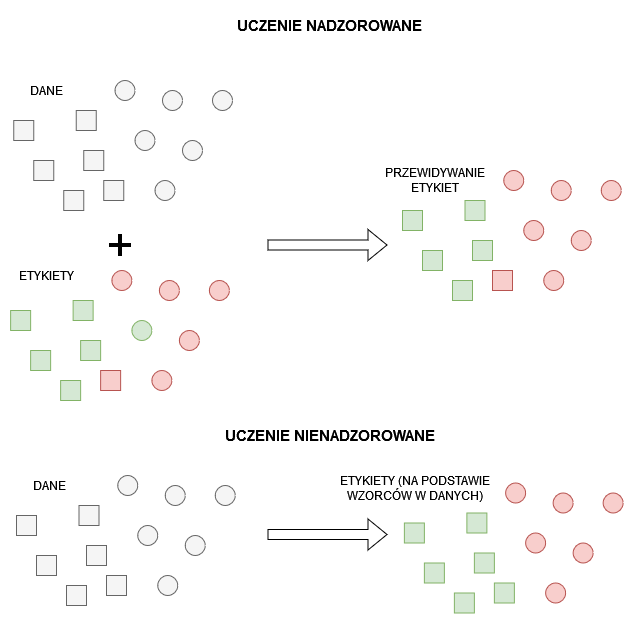

## Algorytm k-means

Najprostszy algorytm klasteryzacji (algorytm k-średnich) dzieli zbiór na założoną z góry liczbę klastrów (skupień). Na początku, centra klastrów są wylosowane, a następnie w każdym kroku punkty przypisywane są do tego klastra, którego centrum leży najbliżej. Centrum przesuwane jest w stronę średniej (np. arytmetycznej) pozycji wszystkich punktów należących do jego klastra. Procedura jest powtarzana określoną liczbę iteracji lub do momentu, gdy centra klastrów przestaną się przesuwać.

Poniżej przedstawiono działanie oraz implementacje algorytmu k-means w sklearn.

<img src="https://files.realpython.com/media/centroids_iterations.247379590275.gif" width="750" align="center">

Przez to, że początkowe miejsca, gdzie pojawiają się centra klastrów są losowane, algorytm k-średnich jest niedeterministyczny i jego ponowne wywołania mogą dawać różne wyniki.

In [ ]:
# przyjrzyjmy się teraz przykładowi klasteryzacji w pakiecie Sklearn.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from sklearn.datasets import make_blobs
# stworzymy sztuczny zbiór danych za pomocą funkcji make_blobs, która tworzy wybraną liczbę blobów, żeby nie musieć samodzielnie tworzyć punktów za pomocą losowych funkcji
X = make_blobs(n_samples = 200, n_features = 2, centers = 4, cluster_std = 1.8)

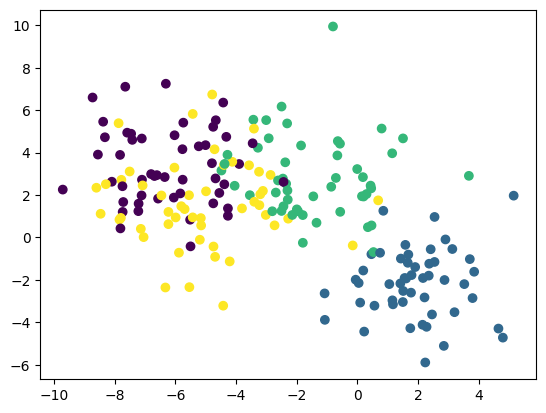

In [ ]:
# podejrzyjmy wygenerowane dane
# dane mają swoje etykiety, ale algorytm nie będzie ich znał - równie dobrze możemy założyć, że ich nie ma.
plt.scatter(X[0][:,0], X[0][:,1], c=X[1])
plt.show()

In [ ]:
# pobieramy klasę KMeans z sklearna
from sklearn.cluster import KMeans

# tworzymy model służący do klasteryzacji, a następnie dopasowujemy (uczymy) go za pomocą funkcji fit
model = KMeans(n_clusters=4)
model.fit(X[0])

KMeans(n_clusters=4)

In [ ]:
# wypiszmy teraz etykiety, jakie algorytm przypisał wszystkim danym. Znajdują się w polu labels_
print('Etykiety nadane przez algorytm:')
print(model.labels_)
print('       ')
# wypiszmy odnalezione centra klastrów
print('Centra klastrów:')
print(model.cluster_centers_)

Etykiety nadane przez algorytm:
[0 1 2 2 2 2 0 2 1 2 2 3 3 0 2 1 1 2 1 0 3 1 1 2 2 2 2 3 2 1 2 1 2 0 1 2 0
 0 3 3 2 1 1 0 2 3 2 3 2 0 0 0 3 1 0 2 0 3 2 3 2 2 1 2 0 2 0 3 0 1 2 0 0 1
 1 0 2 0 0 2 0 1 3 3 3 0 1 1 1 0 2 1 2 3 1 0 2 1 2 1 2 2 3 1 1 1 1 1 1 1 1
 1 1 2 1 3 2 1 3 0 2 2 3 3 3 0 3 1 2 2 2 0 2 3 3 3 1 3 0 2 0 3 0 1 1 3 3 2
 2 1 0 1 0 1 2 1 3 1 1 2 2 3 2 3 1 0 3 1 3 1 2 1 2 0 3 2 0 3 0 3 0 0 2 2 1
 0 3 2 2 0 2 2 1 1 0 2 2 1 2 3]
       
Centra klastrów:
[[-5.88043274  0.79409757]
 [ 1.82319756 -1.92741073]
 [-2.04505614  2.90570944]
 [-6.72514453  4.23577477]]


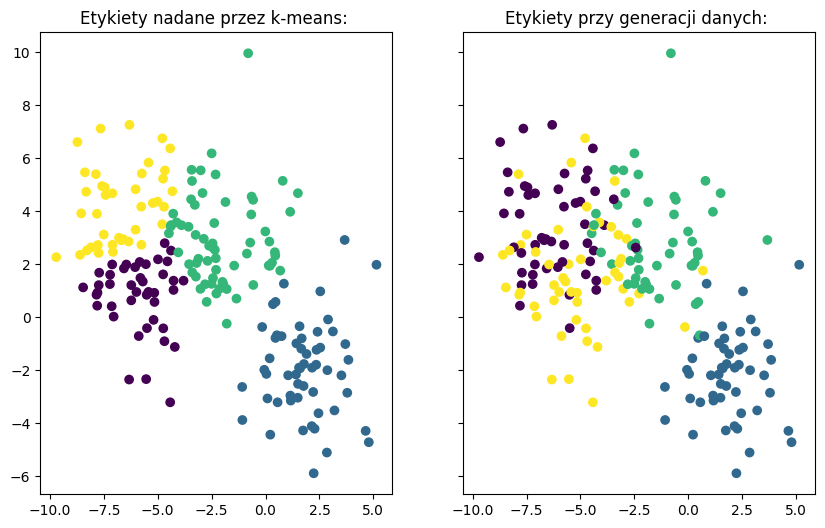

In [ ]:
# teraz obok siebie zobaczmy, jak algorytm podzielił dane, oraz jakie były pierwotne etykiety (których nie znał)
f, (ax1, ax2) = plt.subplots(1, 2, sharey=True,figsize=(10,6))

ax1.set_title('Etykiety nadane przez k-means: ')
ax1.scatter(X[0][:,0], X[0][:,1],c=model.labels_)

ax2.set_title('Etykiety przy generacji danych: ')
ax2.scatter(X[0][:,0], X[0][:,1],c=X[1])

Jakość przypisania klastrów jest określana przez obliczenie sumy błędu kwadratowego (SSE) po zbieżności centroidów lub dopasowaniu przypisania poprzedniej iteracji. SSE definiuje się jako sumę kwadratów odległości euklidesowych każdego punktu do najbliższego centroidu. Ponieważ jest to miara błędu, celem k-średnich jest próba zminimalizowania tej wartości.

Najlepsza liczba skupień (k) będzie więc taka, gdzie odległości pomiędzy centroidami a elementami grupy najmniejsze.

### Klasteryzacja hierarchiczna

Zupełnie innym niż k-means podejściem do klasteryzacji jest algorytm klasteryzacji hierarchicznej. W najpopularniejszej jego metodzie, zwanej aglomeracyjną, na początku zakładamy, że każdy punkt jest osobnym klastrem. W każdym kroku algorytmu łączymy dwa klastry, których odległość jest najmniejsza, w jedno skupienie. Wykonujemy tą operację, aż zostanie nam tyle klastrów, ile oczekujemy.

Klasteryzacja hierarchiczna jest deterministyczna i bardziej elastyczna - w wypadku k-means, żeby otrzymać inną ilość klastrów musimy powtórzyć cały algorytm. W wypadku klasteryzacji hierarchicznej wystarczy cofnąć się o krok algorytmu albo wykonać o krok więcej.

Poniżej znajduje się przykład klasteryzacji hierarchicznej:

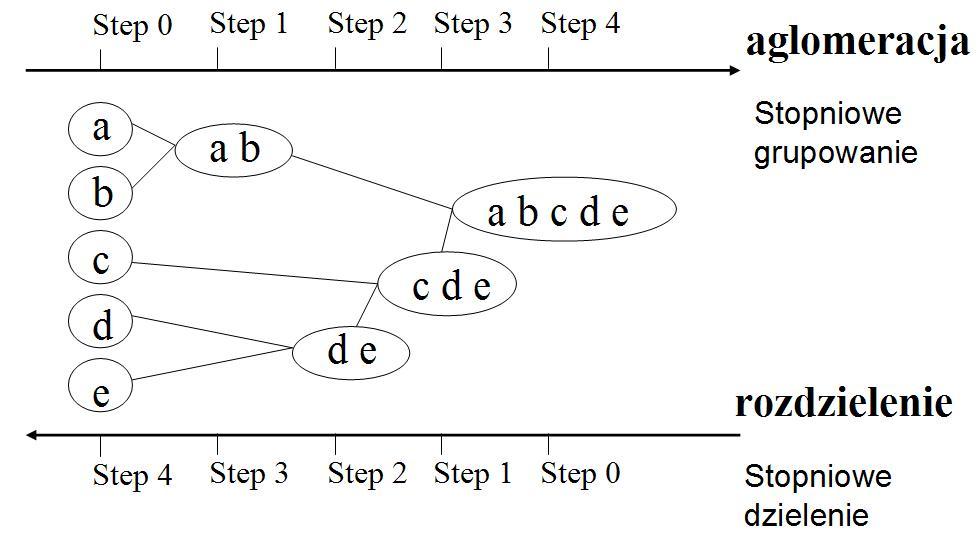

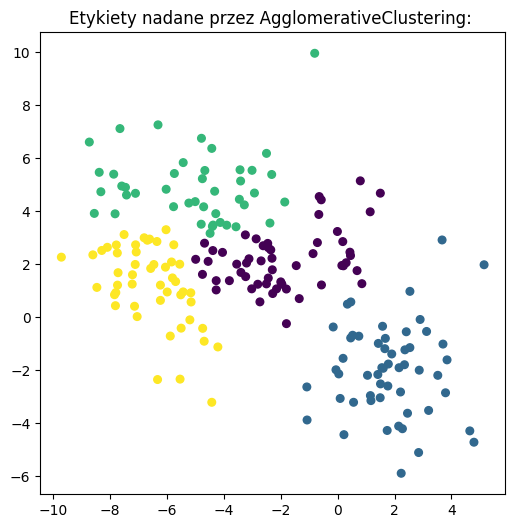

In [ ]:
# pobieramy klasę AgglomerativeClustering z sklearna
from sklearn.cluster import AgglomerativeClustering
# jak w poprzednim przypadku - tworzymy model i uczymy go (dla tych samych danych jak w przypadku k-means)
model = AgglomerativeClustering(n_clusters = 4)
model.fit(X[0])

# zwizualizujmy wyniki na wykresie
plt.figure(figsize =(6, 6))
plt.title('Etykiety nadane przez AgglomerativeClustering: ')
plt.scatter(X[0][:,0],X[0][:,1],c=model.labels_,s=30)
plt.show()

### Algorytm DBSCAN

DBSCAN należy do algorytmów klasteryzacji opartej na gęstości. To zaś polega na budowaniu segmentów na podstawie informacji o zagęszczeniu obserwacji w przestrzeni. Poprzez zagęszczenie należy rozumieć odległości dzielące poszczególne obserwacje w danym obszarze. Jest on często jednym z najlepszych rozwiązań kiedy klastry mają niewypukłe kształty. W przeciwieńtwie pozostałych przedstawionych rozwiązań nie umożliwia definiowania liczby powstałych grup. Odbywa się ona wyłącznie za pomocą zmiany parametrów definiowanych w modelu (minimalnej odległości epsilon oraz minimalnej ilości elementów potrzebnych do powstania zgrupowania).

Nie wszystkie elementy muszą zostać przypisane do grup. Te, które nie będą ułożone "wystarczająco gęsto" zostaną przez algorytm oznaczone jako szum.


![gif dbscan!](https://miro.medium.com/v2/resize:fit:1400/1*Wlb4XzugO5k2SuUc3BDZGg.gif)



In [ ]:
# stworzmy model DBSCAN na tych samych, generowanych danych
# pobieramy klasę DBSCAN z sklearna
from sklearn.cluster import DBSCAN

# przy tworzeniu modelu podajemy dwa parametry: eps i min_samples
# należy pamietać, że model nie daje możliwości podania ilości klastrów - zajmuje się tym sam :)
model = DBSCAN(eps=1.5, min_samples=7)
# uczymy model
model.fit(X[0])
# przypisujemy do zmiennej nadane przez model etykiety klas z pola labels_
labels = model.labels_

# wyliczamy zaproponowaną przez model ilość klastrów oraz punktów szumu
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)
print('Liczba klastrów wytworzona przez algorytm w procesie uczenia: %d' % n_clusters_)
print(' ')
print('Liczba wskazanych przez algorytm punktów szumu: %d' % n_noise_)


Liczba klastrów wytworzona przez algorytm w procesie uczenia: 1
 
Liczba wskazanych przez algorytm punktów szumu: 13


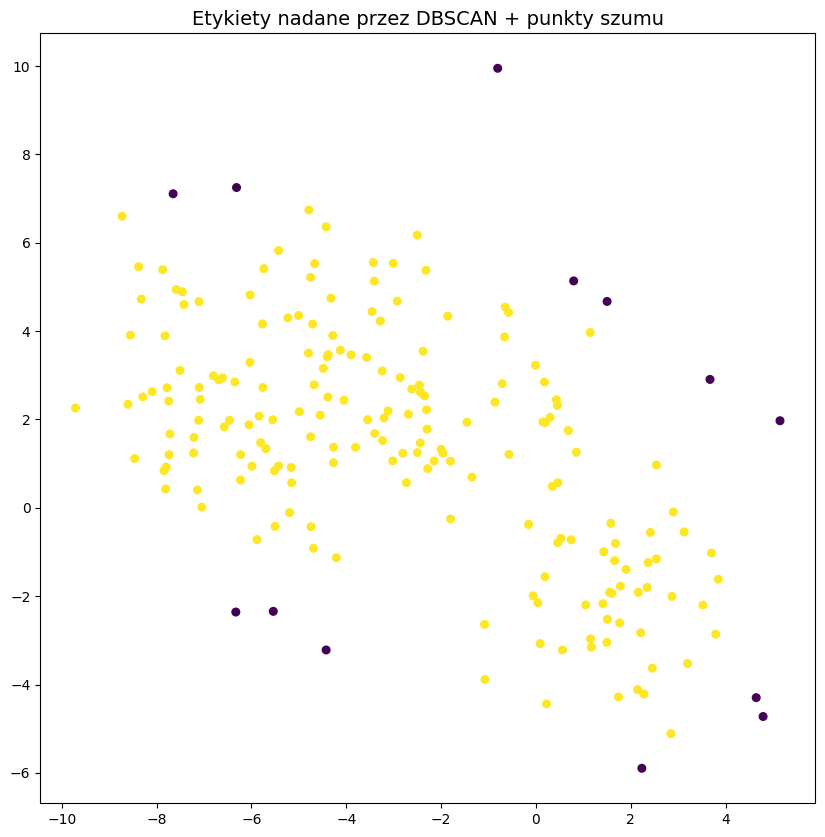

In [ ]:
# zwizualizujmy wyniki na wykresie
plt.figure(figsize=(10,10))
plt.scatter(X[0][:,0],X[0][:,1],c=labels,s=30)
plt.title('Etykiety nadane przez DBSCAN + punkty szumu',fontsize=14)
plt.show()

## Ocena algorytmów klasteryzacyjnych
### Po co w ogóle je oceniać?
1. By ocenić kiedy należy zatrzymać klasteryzację hierarchiczną lub
ocenić czy dobrze określone zostały parametry algorytmu klasteryzacyjnego.
A najbardziej ogólnie: czy to jest to czego szukamy?
2. By porównać rozwiązania uzyskane innymi metodami;
3. By ocenić czy dana metoda jest w danym przypadku aplikowalna (jeśli wiemy jakie powinno być rozwiązanie).


Do omawianych wcześniej zagadnień dotyczących uczenia nadzorowanego używaliśmy takich metryk, które porównywały uzyskany przez model wynik z autentycznymi wartościami. W przypadku klasteryzacji, ze względu na brak tego typu informacji na wejściu taka możliwość nie występuje. **Tutaj klastry są oceniane na podstawie pewnej miary podobieństwa lub odmienności, takiej jak odległość między punktami skupień. Najogólniej - jeśli algorytm  oddziela różne obserwacje a grupuje podobne to działa dobrze.**

Najpopularniejsze metryki oceny dla algorytmów klasteryzacji to współczynnik sylwetkowy (Silhouette score), Daviesa-Bouldin score, Caliński-Harabasz score oraz Indeks Randa. Poniżej opisane zostało ich działanie. Po szczegółowe wzory jednak odsyłamy do dokumentacji.

### Silhouette

Współczynnik sylwetkowy mieści się w zakresie od -1 do 1, gdzie wyższe wartości odnoszą się do modelu z bardziej spójnymi skupieniami. Współczynniki sylwetkowe bliskie +1 oznaczają, że obserwacje jednego klastra znajdują daleko od sąsiednich klastrów. Wartość 0 świadczy o tym, że jest to bardzo blisko granicy decyzyjnej między dwoma sąsiednimi skupieniami. Wartości ujemne tej metryki z kolei mogą wskazywać na to, że próbki mogły zostać potencjalnie przypisane do niewłaściwego skupienia.

Współczynnik jest wyższy dla gęstych i wypukłych grup (np. otrzymanych z k-means), natomiast może być zawodny dla niewypukłych grup, które może zwrócić np. DBSCAN.

In [ ]:
from sklearn import metrics
#  wyliczenie metryki Silhouette dla powyzszego algorytmu DBSCAN
print("Sihouette Score: %0.3f"
      % metrics.silhouette_score(X[0], labels))

Sihouette Score: 0.282


## Davies-Bouldin Index

Davies-Bouldin Index (DB) to miara jakości klasteryzacji, która ocenia jednocześnie:
- zwartość klastrów (czy punkty w klastrze są blisko siebie),
- separację klastrów (czy klastry są od siebie oddalone).

Dla każdego klastra obliczamy:
- jego rozproszenie (średnia odległość punktów od centroidu),
- oraz porównujemy go z najbardziej podobnym (najbliższym) klastrem.

Następnie wynik to średnia z takich „najgorszych przypadków”.

### Intuicja

Dobre klastrowanie oznacza małe, zwarte klastry oraz duże odległości między nimi.

### Interpretacja wyniku

- DB → 0 → bardzo dobre klastrowanie  
- DB < 1 → dobre  
- DB ≈ 1–2 → umiarkowane  
- DB > 2 → słabe  

Im niższy wynik, tym lepiej.

In [ ]:
#  wyliczenie DB Score dla powyzszego algorytmu DBSCAN
print("DB Score : %0.3f"
      % metrics.davies_bouldin_score(X[0], labels))

DB Score : 4.733


## Indeks Caliński-Harabasz

Indeks Caliński-Harabasz (CHI) to miara jakości klasteryzacji, która ocenia stosunek:
- rozdzielenia klastrów (odległości pomiędzy centrami klastrów),
- do zróżnicowania danych wewnątrz klastrów (mierzonego sumą odległości punktów od centrów klastrów).

Miara ta preferuje rozwiązania, w których:
- klastry są dobrze od siebie oddzielone,
- oraz jednocześnie bardzo zwarte wewnętrznie.

### Intuicja

Dobre klastrowanie oznacza duże odległości między klastrami oraz małe rozproszenie punktów w ich obrębie.

### Interpretacja wyniku

- CHI → 0 → bardzo słabe klastrowanie  
- niskie wartości → słaba separacja i/lub duże rozproszenie  
- wysokie wartości → dobre klastrowanie  

Wartości CHI rosną wraz z jakością klasteryzacji i mogą dążyć do nieskończoności.

Im wyższy wynik, tym lepiej.

In [ ]:
print("CHI Score : %0.3f"
      % metrics.calinski_harabasz_score(X[0], labels))

CHI Score : 2.902


### Zastosowanie indeksu Randa

Indeks Randa może być używany do porównywania dwóch klasteryzacji tego samego zbioru danych.

Możemy porównywać:
- wyniki dwóch różnych algorytmów (np. KMeans vs DBSCAN),
- wyniki tego samego algorytmu dla różnych parametrów (np. różna liczba klastrów),
- wynik klasteryzacji z „prawdziwymi” etykietami (jeśli są dostępne).

Indeks Randa odpowiada na pytanie:
czy dwa podziały danych podejmują podobne decyzje dla par punktów, tzn.:
- czy te same punkty trafiają do tego samego klastra,
- oraz czy te same punkty są rozdzielane.

### Uwaga

Indeks Randa należy do miar zewnętrznych, czyli takich, które wymagają porównania dwóch podziałów danych.

W odróżnieniu od miar takich jak:
- Davies-Bouldin,
- Calinski-Harabasz,

które oceniają jakość klasteryzacji na podstawie samych danych,  
Indeks Randa porównuje zgodność dwóch różnych przypisań klastrów.

### Praktyczna uwaga

W praktyce często stosuje się również Adjusted Rand Index (ARI),  
który koryguje wynik o przypadkową zgodność.

Wartość ARI:
- ≈ 0 oznacza losowe przypisanie,
- 1 oznacza idealne dopasowanie.

In [ ]:
#  wyliczenie wartości indeksu Randa dla powyzszego algorytmu DBSCAN
print("Rand Score : %0.3f"
      % metrics.rand_score(X[1], labels))

Rand Score : 0.308


## Zadania do samodzielnego wykonania

1.

Proszę pobrać plik customers_mall.csv, zawierający informacje o klientach pewnego centrum handlowego. Pierwsza kolumna przedstawia ich zarobki (w tysiącach), w drugiej zaś znajduje się punktowa ocena wydatków (od 0 do 100) każdego z klientów.  Proszę dokonać klasteryzacji zbioru z użyciem algorytmu k-means. Uzyskane wyniki należy zwizualizować, ocenić i opisać. Wskazane jest zarekomendowanie odpowiedniej ilości klastrów.

2.

W pliku planets.csv mają państwo zbiór 778 spośród ponad 6000 znanych egzoplanet (planet pozasłonecznych) pozyskany z bazy danych NASA (https://exoplanetarchive.ipac.caltech.edu/index.html). Proszę dokonać klasteryzacji tego zbioru kilkoma sposobami, ocenić wyniki za pomocą odpowiednich metryk, wybrać dowolny z wyników i jego rezultaty (czym się charakteryzują klastry).

Poniżej znajduje się opis kolumn do zestawu danych:


         pl_name:        Planet Name,
         pl_orbper:      Orbital Period [days]',
         pl_orbsmax:     Orbit Semi-Major Axis [au]),
         pl_rade:        Planet Radius [Earth Radius],
         pl_masse:       Planet Mass [Earth Mass],
         pl_orbeccen:    Eccentricity,
         pl_eqt:         Equilibrium Temperature [K],
         st_teff:        Stellar Effective Temperature [K],
         st_mass:        Stellar Mass [Solar mass],
         sy_dist:        Distance [pc]

3.

Dla zbioru danych circle.csv proszę, wykorzystując wszystkie (za wyjątkiem c-means) poznane do tej pory algorytmy klasteryzacyjne, podjąć kilka prób dopasowania jak najlepszego modelu, za każdym razem oceniając rozwiązanie z użyciem dedykowanych do tego metryk. Który z algorytmów najlepiej radzi sobie z takim układem danych i dlaczego? Proszę przedstawić wyniki również w formie odpowiednich wizualizacji.
___________________________________
## Dodatkowe materiały
* https://matteucci.faculty.polimi.it/Clustering/tutorial_html/cmeans.html
* https://pythonhosted.org/scikit-fuzzy/auto_examples/plot_cmeans.html


# Dla zainteresowanych

## Fuzzy clustering (klastrowanie miękkie, fuzzy c-means)

Fuzzy clustering, w szczególności algorytm fuzzy c-means, to metoda klasteryzacji oparta na podejściu rozmytym, w której punkt danych może należeć do wielu klastrów jednocześnie.

W klasycznych algorytmach klasteryzacji (np. KMeans) przynależność punktu do klastra jest jednoznaczna:
- 0 – punkt nie należy do klastra,
- 1 – punkt należy do klastra.

Oznacza to, że granice między klastrami są wyraźne.

W fuzzy c-means przynależność punktu do klastrów opisana jest za pomocą funkcji przynależności:
- wartości należą do przedziału od 0 do 1,
- każdy punkt ma stopień przynależności do każdego klastra.

Reprezentuje się to za pomocą macierzy przynależności, gdzie:
- wiersze odpowiadają punktom,
- kolumny odpowiadają klastrom,
- wartości określają siłę przynależności punktu do danego klastra.

### Intuicja

Punkt może jednocześnie należeć do kilku klastrów, np.:
- 0.7 do klastra A,
- 0.3 do klastra B.

Oznacza to, że znajduje się „pomiędzy” klastrami.

### Właściwości

- granice między klastrami są rozmyte,
- model lepiej radzi sobie z danymi o nieostrych granicach,
- pozwala uchwycić niepewność przynależności.

### Interpretacja

- wartości bliskie 1 → silna przynależność do klastra  
- wartości bliskie 0 → słaba przynależność  
- wartości pośrednie → punkt leży między klastrami

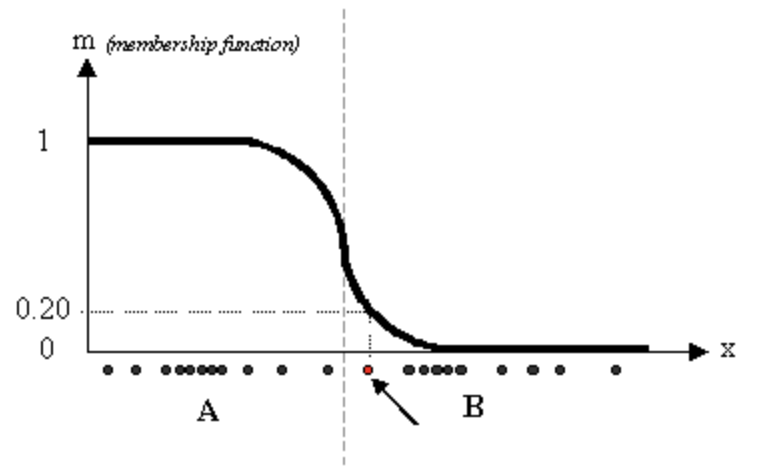


In [ ]:
!pip install scikit-fuzzy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 14.7 MB/s eta 0:00:00


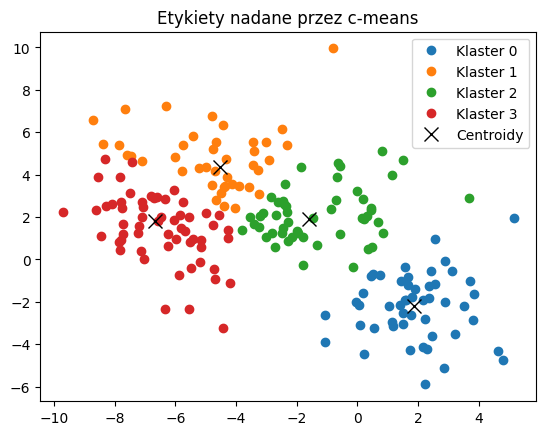

In [ ]:
import skfuzzy as fuzz
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------
# Przygotowanie danych
# ----------------------------------------

# Zakładamy, że X[0] to macierz o wymiarach (n_samples, 2),
# czyli dane 2D (np. współrzędne punktów)
# skfuzzy oczekuje danych w formacie (features, samples),
# dlatego wykonujemy "transpose-like" stacking:
# - pierwszy wiersz: wszystkie wartości cechy 1
# - drugi wiersz: wszystkie wartości cechy 2
all_data = np.vstack((X[0][:, 0], X[0][:, 1]))

# ----------------------------------------
# Model fuzzy c-means
# ----------------------------------------

# Wywołanie algorytmu fuzzy c-means
# Parametry:
# - all_data: dane wejściowe (features x samples)
# - 4: liczba klastrów
# - 2: parametr m (tzw. fuzziness coefficient)
#      m=1 → twarde klastrowanie (jak KMeans)
#      m>1 → bardziej "rozmyte" przypisania (typowo m=2)
# - error: kryterium stopu (zmiana funkcji celu między iteracjami)
# - maxiter: maksymalna liczba iteracji

cntr, u_orig, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    all_data,
    c=4,
    m=2,
    error=0.005,
    maxiter=1000
)

# ----------------------------------------
# Co zwraca c-means?
# ----------------------------------------

# cntr  -> współrzędne centrów klastrów (centroidy)
# u_orig -> macierz przynależności (clusters x samples)
#           każda kolumna sumuje się do 1
#           np. punkt może mieć:
#           [0.7, 0.2, 0.1, 0.0]
# u0    -> początkowa macierz przynależności (losowa inicjalizacja)
# d     -> macierz odległości punktów od centrów
# jm    -> historia funkcji celu (dla kolejnych iteracji)
# p     -> liczba iteracji wykonanych przez algorytm
# fpc   -> fuzzy partition coefficient (miara "jakości rozmycia", im wyższa tym lepiej)

# ----------------------------------------
# Wizualizacja wyników
# ----------------------------------------

fig2, ax2 = plt.subplots()
ax2.set_title('Etykiety nadane przez c-means')

# u_orig.argmax(axis=0):
# dla każdego punktu wybieramy klaster,
# do którego ma NAJWIĘKSZY stopień przynależności
# (czyli "utwardzamy" fuzzy clustering do wersji hard)
cluster_membership = u_orig.argmax(axis=0)

# Rysujemy punkty przypisane do poszczególnych klastrów
for j in range(4):
    ax2.plot(
        all_data[0, cluster_membership == j],  # współrzędna x
        all_data[1, cluster_membership == j],  # współrzędna y
        'o',
        label='Klaster ' + str(j)
    )

# Dodatkowo możemy narysować centroidy
ax2.plot(cntr[:, 0], cntr[:, 1], 'kx', markersize=10, label='Centroidy')

ax2.legend()
plt.show()